In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# !pip install keras-tuner -q
import keras_tuner as kt

np.random.seed(42)
tf.random.set_seed(42)

2026-06-29 18:39:26.344665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782758366.658317      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782758366.747057      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782758367.469846      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782758367.469890      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782758367.469894      58 computation_placer.cc:177] computation placer alr

# a. Eksplorasi Data & Preprocessing 

## Loading Data

In [2]:
df_fb = pd.read_csv('/kaggle/input/datasets/aullyanadinek/datauas1-csv/FB.csv')
df_ibm = pd.read_csv('/kaggle/input/datasets/aullyanadinek/datauas1-csv/IBM.csv')

In [267]:
df_fb.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200


In [4]:
df_ibm.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,7.713333,7.713333,7.626667,7.626667,0.618153,387200
1,1962-01-03,7.626667,7.693333,7.626667,7.693333,0.623556,288000
2,1962-01-04,7.693333,7.693333,7.613333,7.616667,0.617343,256000
3,1962-01-05,7.606667,7.606667,7.453333,7.466667,0.605185,363200
4,1962-01-08,7.460000,7.460000,7.266667,7.326667,0.593837,544000


## Ambil kolom Date dan Close saja

In [5]:
fb = df_fb[['Date', 'Close']].copy()
ibm = df_ibm[['Date', 'Close']].copy()

fb['Date'] = pd.to_datetime(fb['Date'])
ibm['Date'] = pd.to_datetime(ibm['Date'])

fb.set_index('Date', inplace=True)
ibm.set_index('Date', inplace=True)
fb.sort_index(inplace=True)
ibm.sort_index(inplace=True)

In [6]:
fb.head()

,Close
Date,
2012-05-18,38.230000
2012-05-21,34.029999
2012-05-22,31.000000
2012-05-23,32.000000
2012-05-24,33.029999


In [7]:
ibm.head()

,Close
Date,
1962-01-02,7.626667
1962-01-03,7.693333
1962-01-04,7.616667
1962-01-05,7.466667
1962-01-08,7.326667


## Eksplorasi Data (EDA)

In [8]:
print("=== Dataset FB ===")
fb.info()

=== Dataset FB ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1980 entries, 2012-05-18 to 2020-04-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1980 non-null   float64
dtypes: float64(1)
memory usage: 30.9 KB


In [9]:
print("=== Dataset IBM ===")
ibm.info()

=== Dataset IBM ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14663 entries, 1962-01-02 to 2020-04-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   14663 non-null  float64
dtypes: float64(1)
memory usage: 229.1 KB


In [10]:
print('=== Dataset FB ===')
print(f'Rentang tanggal: {fb.index.min()} sampai {fb.index.max()}')
print(f'Jumlah data: {len(fb)}')
print()
print('=== Dataset IBM===')
print(f'Rentang tanggal: {ibm.index.min()} sampai {ibm.index.max()}')
print(f'Jumlah data: {len(ibm)}')

=== Dataset FB ===
Rentang tanggal: 2012-05-18 00:00:00 sampai 2020-04-01 00:00:00
Jumlah data: 1980

=== Dataset IBM===
Rentang tanggal: 1962-01-02 00:00:00 sampai 2020-04-01 00:00:00
Jumlah data: 14663


In [11]:
print('=== Statistik Deskriptif FB ===')
print(fb.describe())
print()
print('=== Statistik Deskriptif IBM ===')
print(ibm.describe())

=== Statistik Deskriptif FB ===
             Close
count  1980.000000
mean    112.312207
std      58.133793
min      17.730000
25%      64.762499
50%     113.810001
75%     168.085003
max     223.229996

=== Statistik Deskriptif IBM ===
              Close
count  14663.000000
mean      60.140033
std       57.353260
min        4.080000
25%       16.110937
50%       28.656250
75%      102.311249
max      215.800003


### Check Missing Value

In [ ]:
print('=== Missing Values FB ===')
print(fb.isnull().sum())
print()
print('=== Missing Values IBM ===')
print(ibm.isnull().sum())

=== Missing Values FB ===
Close    0
dtype: int64

=== Missing Values IBM ===
Close    0
dtype: int64


### Check Duplicate Data

In [13]:
print(f'Duplikasi FB: {fb.index.duplicated().sum()}')
print(f'Duplikasi IBM: {ibm.index.duplicated().sum()}')

Duplikasi FB: 0
Duplikasi IBM: 0


### Visualisasi Harga Close

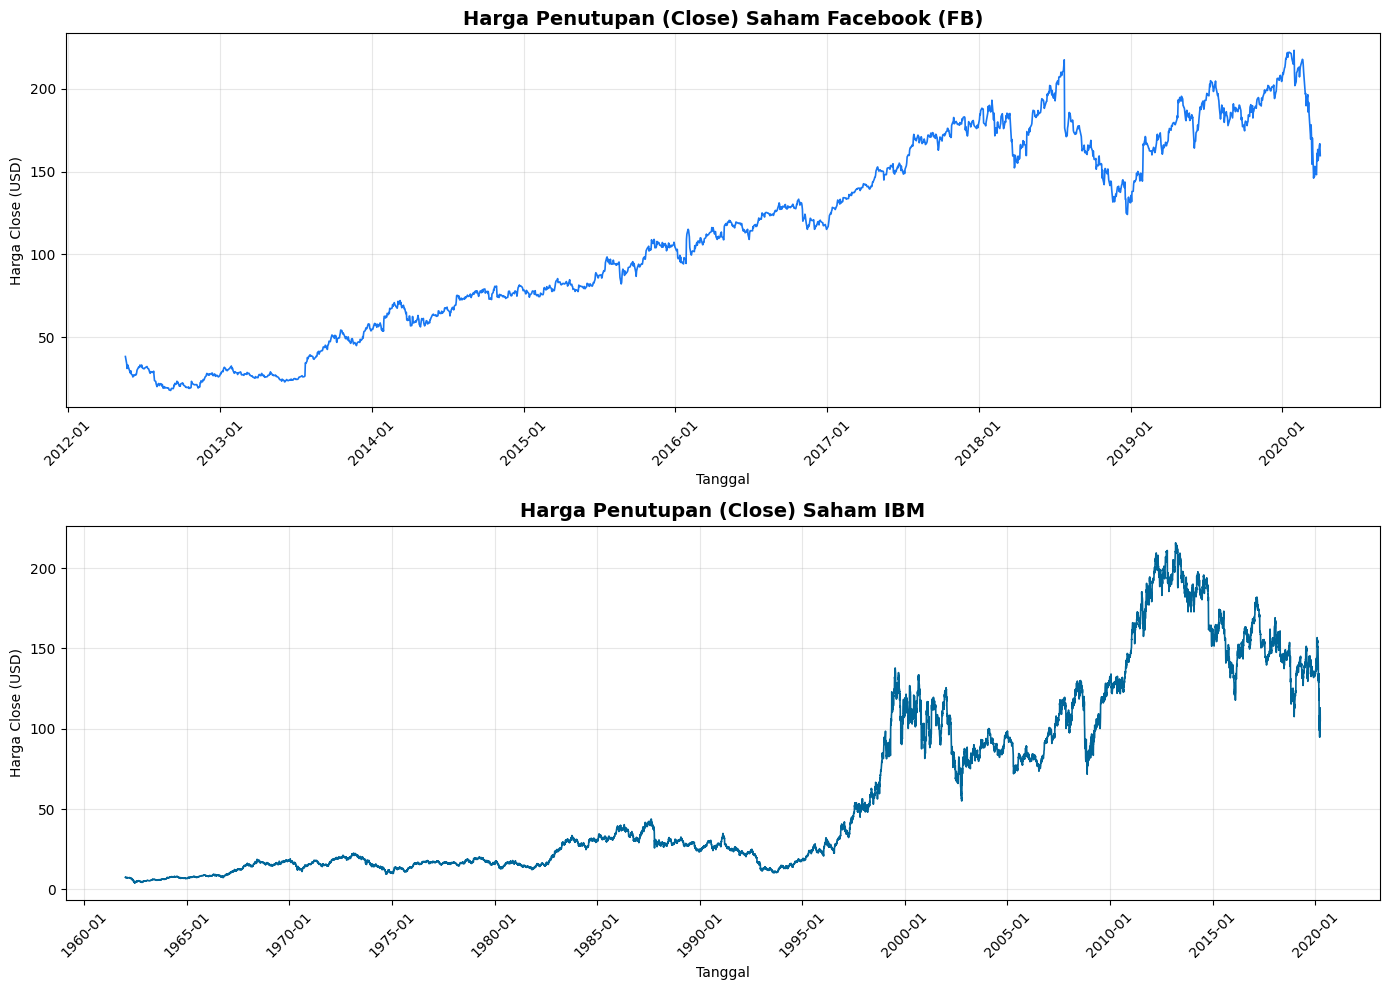

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(fb.index, fb['Close'], color='#1877F2', linewidth=1.2)
axes[0].set_title('Harga Penutupan (Close) Saham Facebook (FB)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Harga Close (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(ibm.index, ibm['Close'], color='#006699', linewidth=1.2)
axes[1].set_title('Harga Penutupan (Close) Saham IBM', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Harga Close (USD)')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(5))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa saham **Facebook (FB)** memiliki tren kenaikan yang relatif konsisten dengan beberapa koreksi harga, sedangkan **IBM** menunjukkan pergerakan yang lebih fluktuatif dan kompleks. Adanya pola tren dan ketergantungan waktu pada kedua saham menjadikan data ini sesuai untuk dimodelkan menggunakan **LSTM**, yang dirancang untuk mempelajari pola temporal pada deret waktu.

### Distribusi Harga Close

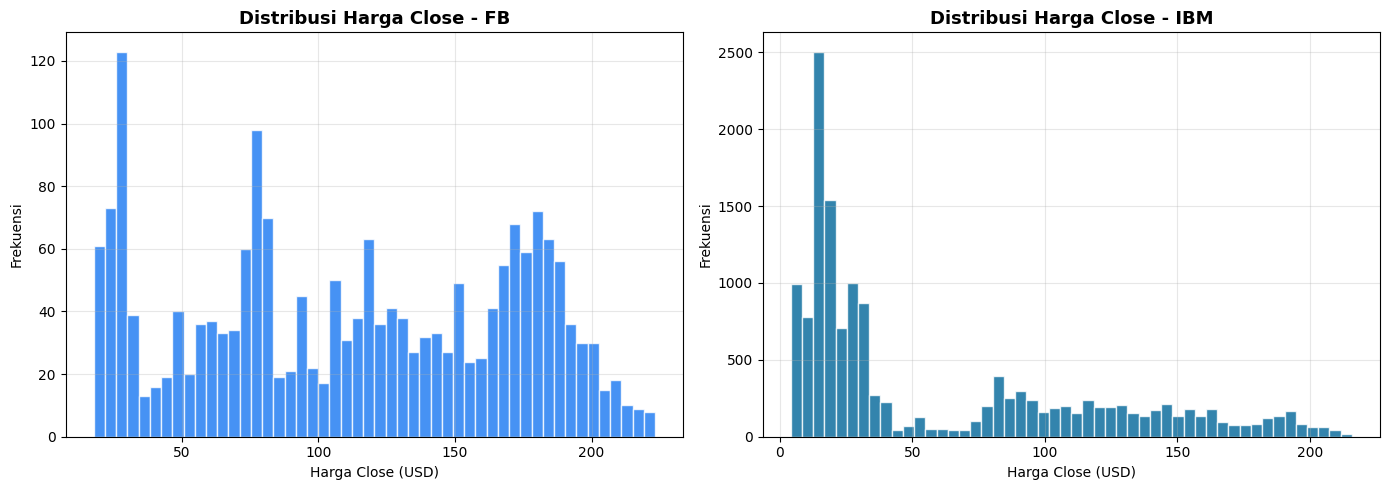

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fb['Close'], bins=50, color='#1877F2', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Harga Close - FB', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga Close (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].grid(True, alpha=0.3)

axes[1].hist(ibm['Close'], bins=50, color='#006699', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Harga Close - IBM', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Harga Close (USD)')
axes[1].set_ylabel('Frekuensi')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Histogram menunjukkan bahwa distribusi harga penutupan saham FB relatif tersebar pada rentang harga yang luas, mencerminkan pertumbuhan harga yang cukup konsisten selama periode pengamatan. Sebaliknya, distribusi harga IBM lebih terkonsentrasi pada harga rendah hingga menengah dengan ekor yang panjang ke arah harga tinggi, yang menunjukkan adanya perubahan harga yang signifikan dalam beberapa periode tertentu. Perbedaan ini mengindikasikan bahwa FB mengalami kenaikan harga yang lebih bertahap, sedangkan IBM memiliki dinamika harga yang lebih bervariasi sepanjang sejarah datanya.

### Harga Close vs Moving Average

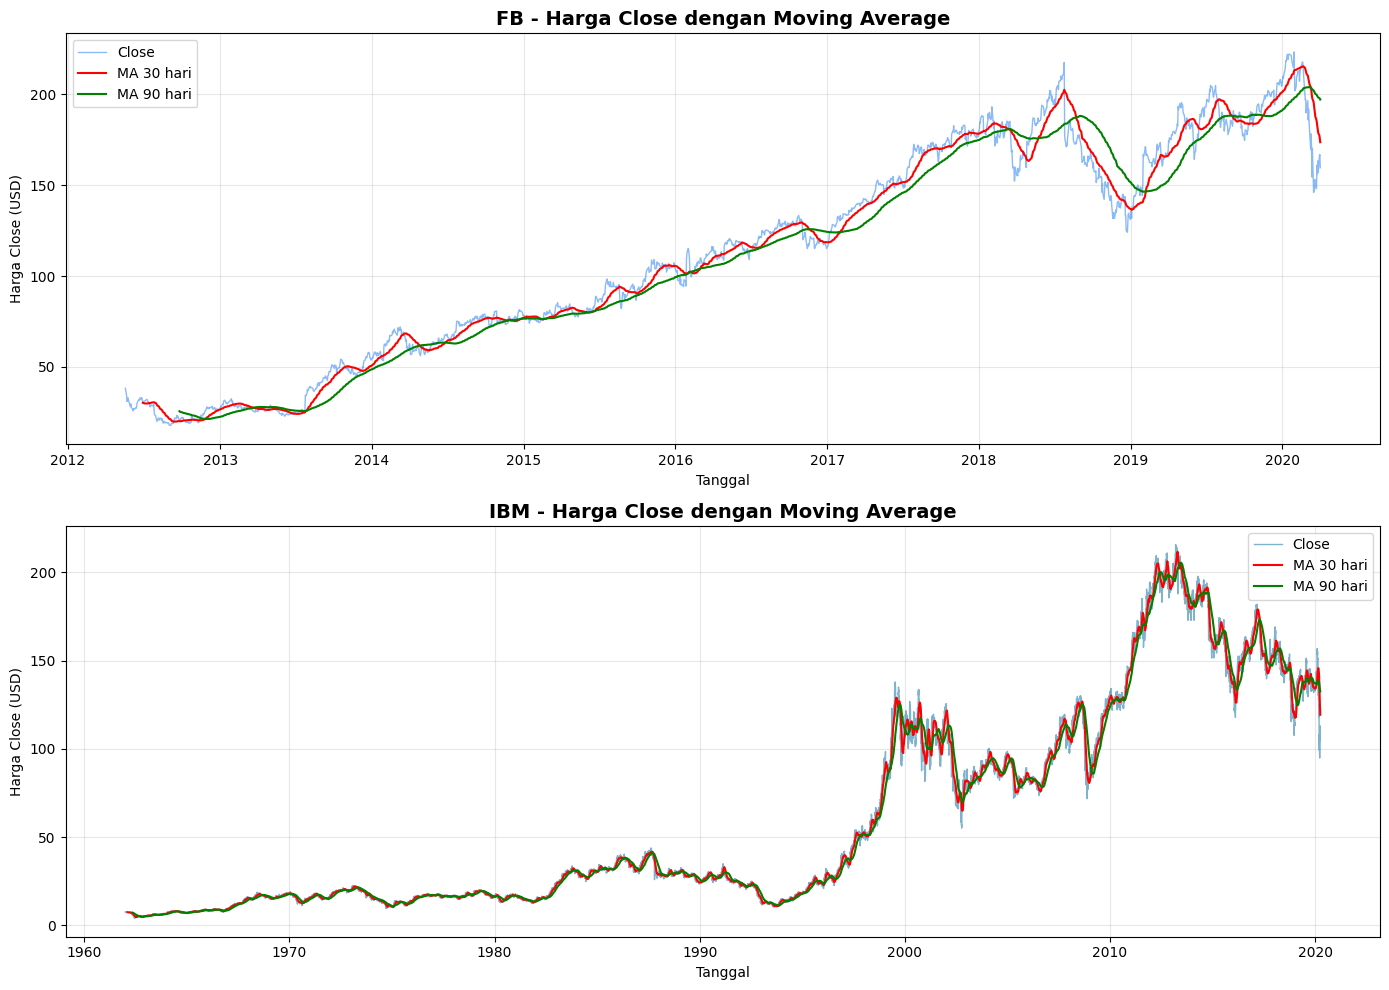

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(fb.index, fb['Close'], color='#1877F2', alpha=0.5, label='Close', linewidth=1)
axes[0].plot(fb.index, fb['Close'].rolling(window=30).mean(), color='red', label='MA 30 hari', linewidth=1.5)
axes[0].plot(fb.index, fb['Close'].rolling(window=90).mean(), color='green', label='MA 90 hari', linewidth=1.5)
axes[0].set_title('FB - Harga Close dengan Moving Average', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Harga Close (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ibm.index, ibm['Close'], color='#006699', alpha=0.5, label='Close', linewidth=1)
axes[1].plot(ibm.index, ibm['Close'].rolling(window=30).mean(), color='red', label='MA 30 hari', linewidth=1.5)
axes[1].plot(ibm.index, ibm['Close'].rolling(window=90).mean(), color='green', label='MA 90 hari', linewidth=1.5)
axes[1].set_title('IBM - Harga Close dengan Moving Average', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Harga Close (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grafik moving average menunjukkan bahwa saham FB memiliki tren kenaikan yang cukup jelas, dengan MA 30 hari dan MA 90 hari bergerak searah mengikuti peningkatan harga dalam jangka panjang. Pada saham IBM, pergerakan MA lebih sering berubah arah mengikuti fluktuasi harga yang lebih besar, meskipun tetap mampu menggambarkan tren umum pasar. Secara keseluruhan, penggunaan moving average membantu menghaluskan noise harian dan memperjelas pola tren yang mendasari pergerakan harga kedua saham.

## Train-Test Split
- **Test set** mencakup **1 tahun terakhir** dari data
- Sisanya digunakan sebagai **training data**

In [16]:
def split_train_test(data):
    last_date = data.index.max()
    cutoff_date = last_date - pd.DateOffset(years=1)
    
    train = data[data.index <= cutoff_date]
    test = data[data.index > cutoff_date]
    
    print(f'Cutoff date: {cutoff_date.date()}')
    print(f'Train set: {train.index.min().date()} sampai {train.index.max().date()} ({len(train)} data)')
    print(f'Test set: {test.index.min().date()} sampai {test.index.max().date()} ({len(test)} data)')
    
    return train, test

print('=== Split FB ===')
fb_train, fb_test = split_train_test(fb)
print()
print('=== Split IBM ===')
ibm_train, ibm_test = split_train_test(ibm)

=== Split FB ===
Cutoff date: 2019-04-01
Train set: 2012-05-18 sampai 2019-04-01 (1727 data)
Test set: 2019-04-02 sampai 2020-04-01 (253 data)

=== Split IBM ===
Cutoff date: 2019-04-01
Train set: 1962-01-02 sampai 2019-04-01 (14410 data)
Test set: 2019-04-02 sampai 2020-04-01 (253 data)


### Visualisasi Split Train Test

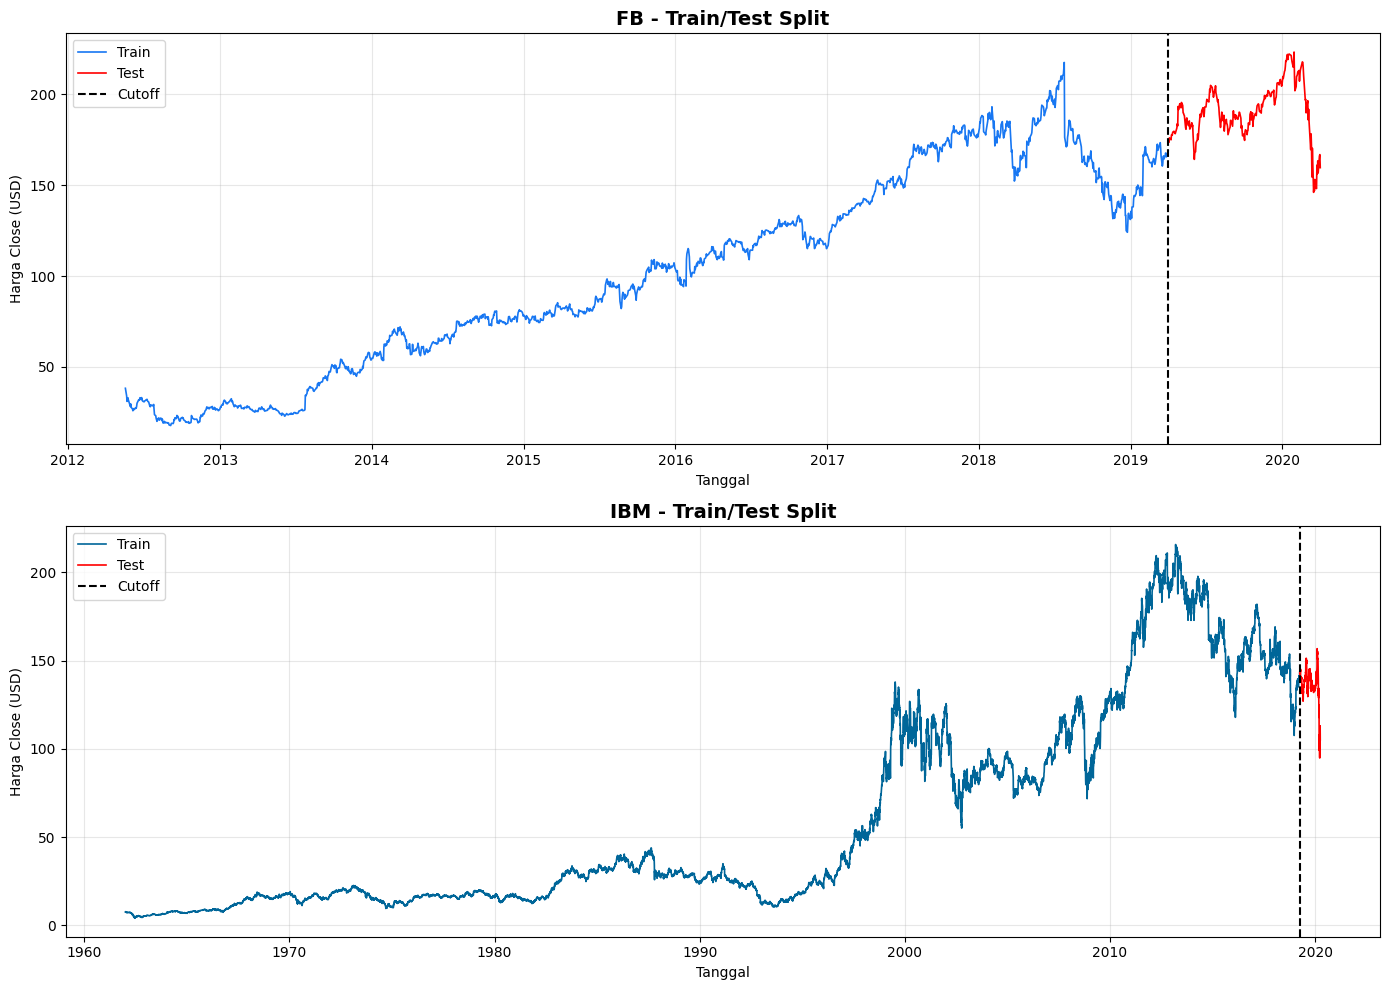

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(fb_train.index, fb_train['Close'], color='#1877F2', label='Train', linewidth=1.2)
axes[0].plot(fb_test.index, fb_test['Close'], color='red', label='Test', linewidth=1.2)
axes[0].axvline(x=fb_train.index.max(), color='black', linestyle='--', label='Cutoff')
axes[0].set_title('FB - Train/Test Split', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Harga Close (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ibm_train.index, ibm_train['Close'], color='#006699', label='Train', linewidth=1.2)
axes[1].plot(ibm_test.index, ibm_test['Close'], color='red', label='Test', linewidth=1.2)
axes[1].axvline(x=ibm_train.index.max(), color='black', linestyle='--', label='Cutoff')
axes[1].set_title('IBM - Train/Test Split', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Harga Close (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Normalisasi Data

Menggunakan **MinMaxScaler** untuk menormalisasi data ke rentang [0, 1]. Scaler di-fit hanya pada data training untuk menghindari data leakage.

In [18]:
# FB
fb_scaler = MinMaxScaler(feature_range=(0, 1))
fb_train_scaled = fb_scaler.fit_transform(fb_train[['Close']].values)
fb_test_scaled = fb_scaler.transform(fb_test[['Close']].values)

# IBM
ibm_scaler = MinMaxScaler(feature_range=(0, 1))
ibm_train_scaled = ibm_scaler.fit_transform(ibm_train[['Close']].values)
ibm_test_scaled = ibm_scaler.transform(ibm_test[['Close']].values)

print(f'FB train scaled shape: {fb_train_scaled.shape}, range: [{fb_train_scaled.min():.4f}, {fb_train_scaled.max():.4f}]')
print(f'FB test scaled shape: {fb_test_scaled.shape}')
print(f'IBM train scaled shape: {ibm_train_scaled.shape}, range: [{ibm_train_scaled.min():.4f}, {ibm_train_scaled.max():.4f}]')
print(f'IBM test scaled shape: {ibm_test_scaled.shape}')

FB train scaled shape: (1727, 1), range: [0.0000, 1.0000]
FB test scaled shape: (253, 1)
IBM train scaled shape: (14410, 1), range: [0.0000, 1.0000]
IBM test scaled shape: (253, 1)


## Windowing 

- **Window size = 5**: menggunakan data 5 hari (Senin s.d. Jumat) sebagai input
- **Horizon = 1**: memprediksi 1 hari ke depan (hari Senin) sebagai output

In [19]:
def make_windows(data, window_size=5, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + horizon - 1])
    
    X = np.array(X)
    y = np.array(y).flatten()
    
    return X, y

WINDOW_SIZE = 5
HORIZON = 1

In [ ]:
xfull_fb_train, yfull_fb_train = make_windows(fb_train_scaled, WINDOW_SIZE, HORIZON)
x_fb_test, y_fb_test = make_windows(fb_test_scaled, WINDOW_SIZE, HORIZON)

xfull_ibm_train, yfull_ibm_train = make_windows(ibm_train_scaled, WINDOW_SIZE, HORIZON)
x_ibm_test, y_ibm_test = make_windows(ibm_test_scaled, WINDOW_SIZE, HORIZON)

print('=== FB Windows ===')
print(f'x_train shape: {xfull_fb_train.shape}, y_train shape: {yfull_fb_train.shape}')
print(f'x_test shape: {x_fb_test.shape}, y_test shape: {y_fb_test.shape}')
print()
print('=== IBM Windows ===')
print(f'x_train shape: {xfull_ibm_train.shape}, y_train shape: {yfull_ibm_train.shape}')
print(f'x_test shape: {x_ibm_test.shape}, y_test shape: {y_ibm_test.shape}')

=== FB Windows ===
x_train shape: (1722, 5, 1), y_train shape: (1722,)
x_test shape: (248, 5, 1), y_test shape: (248,)

=== IBM Windows ===
x_train shape: (14405, 5, 1), y_train shape: (14405,)
x_test shape: (248, 5, 1), y_test shape: (248,)


## Split Train & Validation
Splitting train dan validation dilakukan secara kronologis, bukan acak, untuk mempertahankan urutan waktu pada data dan mencegah data leakage dari masa depan ke masa lalu.

In [ ]:
def split_train_val(x, y, val_ratio=0.1):
    split_idx = int(len(x) * (1 - val_ratio))
    
    x_train = x[:split_idx]
    y_train = y[:split_idx]
    x_val = x[split_idx:]
    y_val = y[split_idx:]
    
    return x_train, y_train, x_val, y_val

x_fb_train, y_fb_train, x_fb_val, y_fb_val = split_train_val(xfull_fb_train, yfull_fb_train)

x_ibm_train, y_ibm_train, x_ibm_val, y_ibm_val = split_train_val(xfull_ibm_train, yfull_ibm_train)

print('=== FB Train/Val Split ===')
print(f'Train: X={x_fb_train.shape}, y={y_fb_train.shape}')
print(f'Val:   X={x_fb_val.shape}, y={y_fb_val.shape}')
print(f'Test:  X={x_fb_test.shape}, y={y_fb_test.shape}')
print()
print('=== IBM Train/Val Split ===')
print(f'Train: X={x_ibm_train.shape}, y={y_ibm_train.shape}')
print(f'Val:   X={x_ibm_val.shape}, y={y_ibm_val.shape}')
print(f'Test:  X={x_ibm_test.shape}, y={y_ibm_test.shape}')

=== FB Train/Val Split ===
Train: X=(1549, 5, 1), y=(1549,)
Val:   X=(173, 5, 1), y=(173,)
Test:  X=(248, 5, 1), y=(248,)

=== IBM Train/Val Split ===
Train: X=(12964, 5, 1), y=(12964,)
Val:   X=(1441, 5, 1), y=(1441,)
Test:  X=(248, 5, 1), y=(248,)


# b. Baseline LSTM 



In [234]:
tf.random.set_seed(42)
def build_baseline_lstm(window_size, n_features=1):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(units=50, activation='relu'),
        Dense(units=1)
    ])
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

baseline_fb = build_baseline_lstm(WINDOW_SIZE)
baseline_ibm = build_baseline_lstm(WINDOW_SIZE)

print('=== Arsitektur Baseline LSTM ===')
baseline_fb.summary()

=== Arsitektur Baseline LSTM ===


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_33 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [235]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [236]:
history_baseline_fb = baseline_fb.fit(
    x_fb_train, y_fb_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_fb_val, y_fb_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.1300 - mae: 0.2769 - val_loss: 0.0453 - val_mae: 0.2085
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0035 - mae: 0.0404 - val_loss: 0.0019 - val_mae: 0.0291
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9381e-04 - mae: 0.0130 - val_loss: 0.0012 - val_mae: 0.0216
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6739e-04 - mae: 0.0091 - val_loss: 0.0011 - val_mae: 0.0213
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6269e-04 - mae: 0.0089 - val_loss: 0.0011 - val_mae: 0.0212
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6163e-04 - mae: 0.0088 - val_loss: 0.0011 - val_mae: 0.0212
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6118e-04 - mae: 0.0088 - val_loss: 0.0011 - val_mae: 0.0212
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6075e-04 - mae: 0.0088 - val_loss: 0.0011 - val_mae: 0.0212
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 

In [239]:
history_baseline_ibm = baseline_ibm.fit(
    x_ibm_train, y_ibm_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_ibm_val, y_ibm_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.3689e-05 - mae: 0.0033 - val_loss: 8.4537e-05 - val_mae: 0.0064
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.3088e-05 - mae: 0.0033 - val_loss: 8.4651e-05 - val_mae: 0.0064
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2780e-05 - mae: 0.0032 - val_loss: 8.4911e-05 - val_mae: 0.0064
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2654e-05 - mae: 0.0032 - val_loss: 8.4737e-05 - val_mae: 0.0064
Epoch 5/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2551e-05 - mae: 0.0032 - val_loss: 8.5179e-05 - val_mae: 0.0064
Epoch 6/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2485e-05 - mae: 0.0032 - val_loss: 8.5294e-05 - val_mae: 0.0064
Epoch 7/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2441e-05 - mae: 0.0032 - val_loss: 8.5418e-05 - val_mae: 0.0064
Epoch 8/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2422e-05 - mae: 0.0032 - val_loss: 8.5169e-05 - 

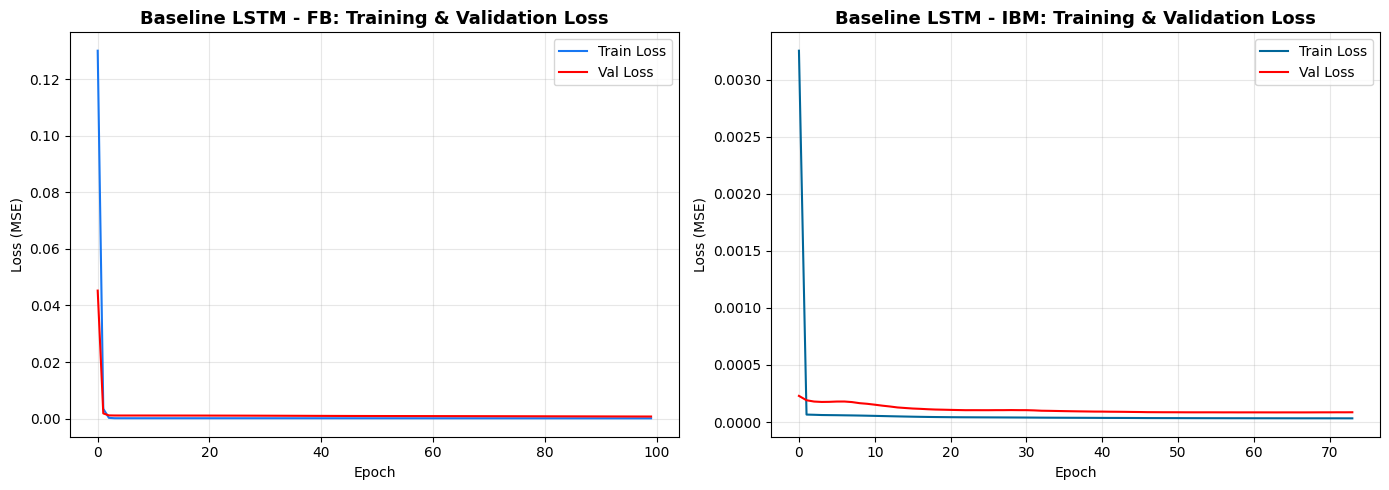

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline_fb.history['loss'], label='Train Loss', color='#1877F2')
axes[0].plot(history_baseline_fb.history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('Baseline LSTM - FB: Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_baseline_ibm.history['loss'], label='Train Loss', color='#006699')
axes[1].plot(history_baseline_ibm.history['val_loss'], label='Val Loss', color='red')
axes[1].set_title('Baseline LSTM - IBM: Training & Validation Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Dikedua grafik terlihat loss train dan validation yang turun dan konvergen dengan cepat. Hal ini menunjukkan bahwa model mampu menangkap pola dasar pergerakan harga, yaitu kecenderungan bahwa harga pada waktu berikutnya tidak jauh berbeda dari harga saat ini (*persistence*), namun belum mampu memanfaatkan informasi temporal yang lebih kompleks. Oleh karena itu, jumlah unit LSTM ditingkatkan dari 50 menjadi **85 unit** untuk memperbesar kapasitas model dalam menyimpan dan mempelajari dependensi jangka pendek maupun jangka panjang pada data harga saham. Selain itu, ditambahkan lapisan **Dense(8, ReLU)** sebelum layer output untuk memberikan transformasi **non-linear** tambahan terhadap representasi temporal yang dihasilkan LSTM. Dengan adanya non-linearitas ini, model tidak lagi hanya melakukan pemetaan sederhana dari output LSTM ke nilai prediksi, tetapi dapat mempelajari hubungan yang lebih kompleks antar fitur temporal. Modifikasi tersebut diharapkan menghasilkan prediksi yang lebih akurat, yang ditunjukkan oleh penurunan nilai RMSE, MAE, dan MAPE.


In [231]:
def test_metrics(model, x_test, y_test, scaler):
    pred = scaler.inverse_transform(model.predict(x_test, verbose=0).reshape(-1, 1)).flatten()
    true = scaler.inverse_transform(np.asarray(y_test).reshape(-1, 1)).flatten()
    mape = mean_absolute_percentage_error(true, pred) * 100
    rmse = root_mean_squared_error(true, pred)
    mae  = mean_absolute_error(true, pred)
    return mape, rmse, mae

fb_mape, fb_rmse, fb_mae = test_metrics(baseline_fb,  x_fb_test,  y_fb_test, fb_scaler)
ibm_mape, ibm_rmse, ibm_mae = test_metrics(baseline_ibm, x_ibm_test, y_ibm_test, ibm_scaler)

In [232]:
print("Dataset FB")
print(f"MAPE: {fb_mape:.4f}")
print(f"RMSE: {fb_rmse:.4f}")
print(f"MAE: {fb_mae:.4f}")

Dataset FB
MAPE: 2.3184
RMSE: 5.5445
MAE: 4.3408


Pada dataset FB, model LSTM menghasilkan nilai **MAPE sebesar 2.3184%**, **RMSE sebesar 5.5445**, dan **MAE sebesar 4.3408**. Nilai MAPE yang berada di bawah 3% menunjukkan bahwa model memiliki tingkat akurasi prediksi yang sangat baik, dengan rata-rata kesalahan prediksi hanya sekitar 2.32% dari nilai aktual. Sementara itu, nilai MAE sebesar 4.3408 menunjukkan bahwa secara rata-rata prediksi model menyimpang sekitar 4.34 poin harga dari nilai sebenarnya. Nilai RMSE yang lebih besar dibandingkan MAE mengindikasikan adanya beberapa prediksi dengan kesalahan yang relatif besar, karena RMSE memberikan penalti lebih tinggi terhadap error ekstrem. Secara keseluruhan, hasil ini menunjukkan bahwa model LSTM mampu menangkap pola pergerakan harga saham FB dengan baik, namun masih dapat ditingkatkan.


In [233]:
print("Dataset IBM")
print(f"MAPE: {ibm_mape:.4f}")
print(f"RMSE: {ibm_rmse:.4f}")
print(f"MAE: {ibm_mae:.4f}")

Dataset IBM
MAPE: 1.3377
RMSE: 2.6901
MAE: 1.7379


Pada dataset IBM, model LSTM memperoleh nilai **MAPE sebesar 1.3377%**, **RMSE sebesar 2.6901**, dan **MAE sebesar 1.7379**. Nilai MAPE yang sangat rendah menunjukkan bahwa rata-rata kesalahan prediksi model hanya sekitar 1.34% dari nilai aktual, sehingga akurasi prediksi dapat dikatakan sangat tinggi. Nilai MAE sebesar 1.7379 menandakan bahwa rata-rata selisih antara hasil prediksi dan nilai aktual hanya sekitar 1.74 poin harga. Selain itu, selisih antara RMSE dan MAE yang tidak terlalu besar menunjukkan bahwa distribusi error cenderung stabil dan tidak banyak dipengaruhi oleh kesalahan ekstrem. Secara keseluruhan, model LSTM menunjukkan performa yang sangat baik pada dataset IBM dan mampu menghasilkan prediksi yang lebih konsisten dibandingkan pada dataset FB. 

Secara absolut, nilai MAPE pada kedua dataset tergolong rendah (1–2%), yang menunjukkan akurasi prediksi yang baik. Namun, RMSE dan MAE pada dataset IBM yang lebih kecil dibanding FB tidak selalu berarti modelnya lebih baik, melainkan dapat dipengaruhi oleh rentang harga IBM yang lebih sempit dan stabil. Oleh karena itu, MAPE yang bersifat relatif dalam persentase lebih tepat digunakan untuk membandingkan performa model antar saham.

# c) Modification

In [244]:
tf.random.set_seed(42)
def build_modified_lstm(window_size, n_features=1):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(units=85, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

fb_modified = build_modified_lstm(WINDOW_SIZE)

In [245]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_fb_modified = fb_modified.fit(
    x_fb_train, y_fb_train,
    epochs=150,
    batch_size=32,
    validation_data=(x_fb_val, y_fb_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0814 - val_loss: 0.0011
Epoch 2/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.0848e-04 - val_loss: 0.0015
Epoch 3/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3663e-04 - val_loss: 0.0013
Epoch 4/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8792e-04 - val_loss: 0.0012
Epoch 5/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8047e-04 - val_loss: 0.0011
Epoch 6/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7584e-04 - val_loss: 0.0011
Epoch 7/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7357e-04 - val_loss: 0.0011
Epoch 8/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7336e-04 - val_loss: 0.0011
Epoch 9/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7401e-04 - val_loss: 0.0011
Epoch 10/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7474e-04 - val_loss: 0.0011
Epoch 11/150
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7506e-04 - val_loss: 0.0011
Epoch 12/150
49/49 ━━━

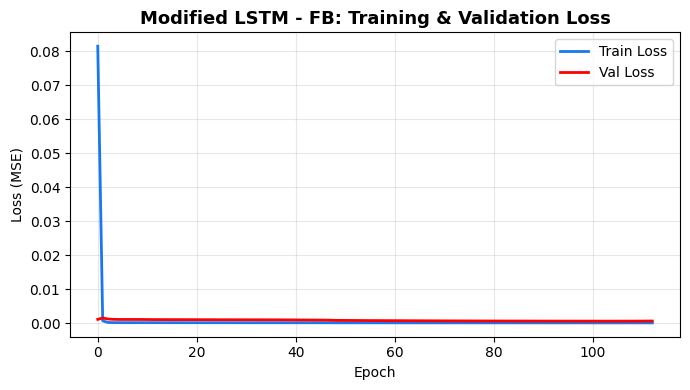

Dataset FB
MAPE: 1.6625
RMSE: 4.1831
MAE: 3.0947


In [246]:
plt.figure(figsize=(7, 4))
plt.plot(history_fb_modified.history['loss'], label='Train Loss', color='#1877F2', linewidth=2)
plt.plot(history_fb_modified.history['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Modified LSTM - FB: Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')    
plt.ylabel('Loss (MSE)')  
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fb_modified_mape, fb_modified_rmse, fb_modified_mae = test_metrics(fb_modified,  x_fb_test,  y_fb_test, fb_scaler)
print("Dataset FB")
print(f"MAPE: {fb_modified_mape:.4f}")
print(f"RMSE: {fb_modified_rmse:.4f}")
print(f"MAE: {fb_modified_mae:.4f}")

Model modifikasi berhasil menurunkan seluruh metrik error pada saham **FB** secara signifikan, dengan **MAPE turun dari 2,32% menjadi 1,66%**. Hasil ini menunjukkan bahwa peningkatan kapasitas LSTM serta penambahan **Dense head** mampu membantu model menangkap pola pergerakan harga yang lebih kompleks dibandingkan hanya mengandalkan pola *persistence*. Dari grafik loss terlihat bahwa model tetap konvergen dengan cepat pada beberapa epoch awal, namun validation loss masih mengalami penurunan secara bertahap setelahnya. Hal ini mengindikasikan bahwa lapisan non-linear tambahan memberikan kapasitas pembelajaran yang lebih baik tanpa mengorbankan kemampuan generalisasi. Selain itu, jarak antara train loss dan validation loss tetap kecil sepanjang pelatihan, sehingga tidak terdapat indikasi overfitting meskipun kompleksitas model meningkat.


In [259]:
tf.random.set_seed(42)
ibm_modified = build_modified_lstm(WINDOW_SIZE)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history_ibm_modified = ibm_modified.fit(
    x_ibm_train, y_ibm_train,
    epochs=150,
    batch_size=32,
    validation_data=(x_ibm_val, y_ibm_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0037 - val_loss: 2.0888e-04
Epoch 2/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.8356e-05 - val_loss: 1.8718e-04
Epoch 3/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.6049e-05 - val_loss: 2.1427e-04
Epoch 4/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5818e-05 - val_loss: 2.2976e-04
Epoch 5/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.5671e-05 - val_loss: 2.1455e-04
Epoch 6/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4281e-05 - val_loss: 1.8677e-04
Epoch 7/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.1758e-05 - val_loss: 1.6838e-04
Epoch 8/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.9000e-05 - val_loss: 1.6250e-04
Epoch 9/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.6459e-05 - val_loss: 1.5922e-04
Epoch 10/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.3912e-05 - val_loss: 1.4690e-04
Epoch 11/150
406/406 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

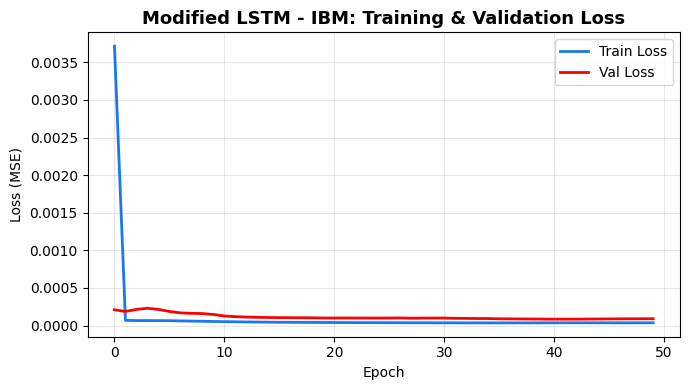

Dataset IBM
MAPE: 1.3272
RMSE: 2.6659
MAE: 1.7199


In [260]:
plt.figure(figsize=(7, 4))
plt.plot(history_ibm_modified.history['loss'], label='Train Loss', color='#1877F2', linewidth=2)
plt.plot(history_ibm_modified.history['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Modified LSTM - IBM: Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')    
plt.ylabel('Loss (MSE)')  
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ibm_modified_mape, ibm_modified_rmse, ibm_modified_mae = test_metrics(ibm_modified,  x_ibm_test,  y_ibm_test, ibm_scaler)
print("Dataset IBM")
print(f"MAPE: {ibm_modified_mape:.4f}")
print(f"RMSE: {ibm_modified_rmse:.4f}")
print(f"MAE: {ibm_modified_mae:.4f}")

Pada saham **IBM**, model modifikasi juga berhasil menurunkan seluruh metrik error, meskipun peningkatannya relatif kecil dibandingkan FB. Hal ini menunjukkan bahwa model baseline sebenarnya sudah cukup optimal dalam menangkap pola pergerakan harga IBM, yang didukung oleh jumlah data pelatihan yang lebih besar. Dari grafik loss terlihat pola yang hampir sama dengan baseline, yaitu konvergensi yang sangat cepat di awal pelatihan kemudian diikuti fase plateau yang panjang. Meskipun demikian, validation loss pada model modifikasi mencapai nilai plateau yang sedikit lebih rendah, yang sejalan dengan perbaikan metrik yang diperoleh. Hasil ini mengindikasikan bahwa peningkatan kapasitas model tetap memberikan manfaat, namun pengaruhnya terbatas karena performa baseline pada dataset IBM sudah cukup kuat.


# d) Evaluasi

In [264]:
comparison_df_fb = pd.DataFrame({
    'Metric': ['MAPE', 'RMSE', 'MAE'],
    'Base Model': [fb_mape, fb_rmse, fb_mae],
    'Modified Model': [fb_modified_mape, fb_modified_rmse, fb_modified_mae],
    'Selisih': [fb_modified_mape-fb_mape, fb_modified_rmse-fb_rmse, fb_modified_mae-fb_mae]
}).set_index('Metric').T

comparison_df_ibm = pd.DataFrame({
    'Metric': ['MAPE', 'RMSE', 'MAE'],
    'Base Model': [ibm_mape, ibm_rmse, ibm_mae],
    'Modified Model': [ibm_modified_mape, ibm_modified_rmse, ibm_modified_mae],
    'Selisih': [ibm_modified_mape-ibm_mape, ibm_modified_rmse-ibm_rmse, ibm_modified_mae-ibm_mae]
}).set_index('Metric').T

df_final_comparison = pd.concat(
    [comparison_df_fb, comparison_df_ibm], 
    axis=1, 
    keys=['Dataset FB', 'Dataset IBM']
)

display(df_final_comparison)

Dataset FB                     Dataset IBM                    
Metric               MAPE      RMSE       MAE        MAPE      RMSE       MAE
Base Model       2.318420  5.544539  4.340766    1.337663  2.690078  1.737873
Modified Model   1.662543  4.183088  3.094734    1.327202  2.665857  1.719921
Selisih         -0.655877 -1.361451 -1.246032   -0.010461 -0.024221 -0.017953

Terlihat bahwa model modifikasi berhasil menurunkan metrik error baik di dataset IBM maupun FB. Namun, saya akan tetap melakukan tuning untuk mementukan kombinasi terbaik dari parameter sehingga mengurangi bias dalam pemilihan arsitektur. Parameter yang akan dituning meliputi jumlah unit LSTM, ukuran dense head, dan fungsi aktivasi. Meskipun penggunaan ReLU pada dense head telah memberikan peningkatan performa yang cukup baik, fungsi aktivasi tanh juga layak dievaluasi karena secara alami lebih sesuai untuk pemodelan data sekuens dan merupakan aktivasi yang digunakan pada mekanisme internal LSTM. Oleh karena itu, kedua fungsi aktivasi tersebut akan dibandingkan untuk mengetahui konfigurasi yang menghasilkan performa terbaik.

Tuning akan menggunalan val_loss bukan metrik dari test set untuk menghindari data leakage.

In [ ]:
def build_tuned(hp):
    model = Sequential()
    model.add(Input((WINDOW_SIZE, 1)))

    model.add(
        LSTM(
            units=hp.Choice('lstm_units', values=[64, 96, 128]),
            activation=hp.Choice('activation', values=['relu', 'tanh'])
        )
    )

    model.add(
        Dense(
            units=hp.Choice('dense_units', values=[8, 16, 32]),
            activation='relu'
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(1e-3),
        loss='mse',
        metrics=['mae']
    )

    return model


tuner_fb = kt.RandomSearch(
    build_tuned,
    objective='val_loss',
    max_trials=18,   
    seed=42,
    directory='kt',
    project_name='fb',
    overwrite=True
)

tuner_fb.search(
    x_fb_train, y_fb_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_fb_val, y_fb_val),
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

best_hp_fb = tuner_fb.get_best_hyperparameters(1)[0]
print("Best FB:", best_hp_fb.values)

Trial 18 Complete [00h 00m 53s]
val_loss: 0.000608383328653872

Best val_loss So Far: 0.0005665180506184697
Total elapsed time: 00h 11m 49s
Best FB: {'lstm_units': 64, 'activation': 'tanh', 'dense_units': 32}


In [289]:
tuned_fb = build_tuned(best_hp_fb)
tuned_fb.summary()

history_tuned_fb = tuned_fb.fit(
    x_fb_train, y_fb_train,
    epochs=100, batch_size=32,
    validation_data=(x_fb_val, y_fb_val),
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0411 - mae: 0.1358 - val_loss: 0.0010 - val_mae: 0.0216
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5437e-04 - mae: 0.0165 - val_loss: 0.0014 - val_mae: 0.0236
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9396e-04 - mae: 0.0098 - val_loss: 0.0013 - val_mae: 0.0229
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7639e-04 - mae: 0.0092 - val_loss: 0.0012 - val_mae: 0.0228
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7370e-04 - mae: 0.0091 - val_loss: 0.0012 - val_mae: 0.0226
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7248e-04 - mae: 0.0090 - val_loss: 0.0012 - val_mae: 0.0224
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7211e-04 - mae: 0.0090 - val_loss: 0.0012 - val_mae: 0.0223
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7307e-04 - mae: 0.0090 - val_loss: 0.0012 - val_mae: 0.0223
Epoch 8: early stopping
Restoring m

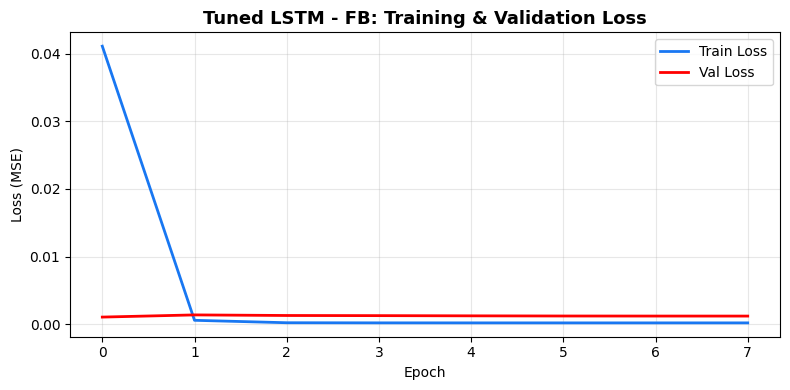

Dataset FB
MAPE: 2.8881
RMSE: 6.5223
MAE: 5.4858


In [290]:
plt.figure(figsize=(8, 4))
plt.plot(history_tuned_fb.history['loss'], label='Train Loss', color='#1877F2', linewidth=2)
plt.plot(history_tuned_fb.history['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Tuned LSTM - FB: Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tuned_fb_mape, tuned_fb_rmse, tuned_fb_mae = test_metrics(tuned_fb, x_fb_test, y_fb_test, fb_scaler)
print("Dataset FB")
print(f"MAPE: {tuned_fb_mape:.4f}")
print(f"RMSE: {tuned_fb_rmse:.4f}")
print(f"MAE: {tuned_fb_mae:.4f}")

In [ ]:
tuner_ibm = kt.RandomSearch(
    build_tuned,
    objective='val_loss',
    max_trials=18,   
    seed=42,
    directory='kt',
    project_name='ibm',
    overwrite=True
)

tuner_ibm.search(
    x_ibm_train, y_ibm_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_ibm_val, y_ibm_val),
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

best_hp_ibm = tuner_ibm.get_best_hyperparameters(1)[0]
print("Best IBM:", best_hp_ibm.values)

Trial 18 Complete [00h 04m 58s]
val_loss: 8.437945507466793e-05

Best val_loss So Far: 8.437945507466793e-05
Total elapsed time: 00h 32m 38s
Best IBM: {'lstm_units': 128, 'activation': 'tanh', 'dense_units': 16}


In [292]:
tuned_ibm = build_tuned(best_hp_ibm)
tuned_ibm.summary()

history_tuned_ibm = tuned_ibm.fit(
    x_ibm_train, y_ibm_train,
    epochs=100, batch_size=32,
    validation_data=(x_ibm_val, y_ibm_val),
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,641 (268.13 KB)

 Trainable params: 68,641 (268.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0020 - mae: 0.0136 - val_loss: 2.1633e-04 - val_mae: 0.0110
Epoch 2/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.8512e-05 - mae: 0.0051 - val_loss: 1.9247e-04 - val_mae: 0.0100
Epoch 3/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.7412e-05 - mae: 0.0051 - val_loss: 1.8776e-04 - val_mae: 0.0099
Epoch 4/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.5621e-05 - mae: 0.0050 - val_loss: 1.8310e-04 - val_mae: 0.0097
Epoch 5/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.4895e-05 - mae: 0.0050 - val_loss: 1.8828e-04 - val_mae: 0.0099
Epoch 6/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.3489e-05 - mae: 0.0050 - val_loss: 2.0285e-04 - val_mae: 0.0105
Epoch 7/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 7.1498e-05 - mae: 0.0050 - val_loss: 2.3729e-04 - val_mae: 0.0117
Epoch 8/100
406/406 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 6.9894e-05 - mae: 0.0050 - val_loss: 1.7834e-04 - val_

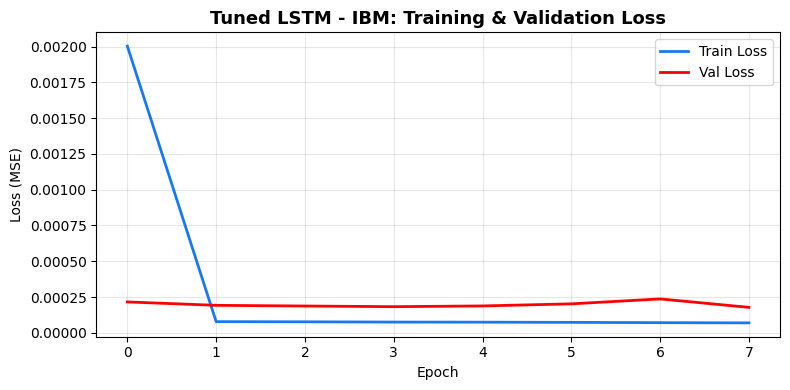

Dataset IBM
MAPE: 2.2022
RMSE: 4.1274
MAE: 2.8904


In [293]:
plt.figure(figsize=(8, 4))
plt.plot(history_tuned_ibm.history['loss'], label='Train Loss', color='#1877F2', linewidth=2)
plt.plot(history_tuned_ibm.history['val_loss'], label='Val Loss', color='red', linewidth=2)
plt.title('Tuned LSTM - IBM: Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tuned_ibm_mape, tuned_ibm_rmse, tuned_ibm_mae = test_metrics(tuned_ibm, x_ibm_test, y_ibm_test, ibm_scaler)
print("Dataset IBM")
print(f"MAPE: {tuned_ibm_mape:.4f}")
print(f"RMSE: {tuned_ibm_rmse:.4f}")
print(f"MAE: {tuned_ibm_mae:.4f}")

In [ ]:
comparison_df_fb = pd.DataFrame({
    'Metric': ['MAPE', 'RMSE', 'MAE'],
    'Baseline': [fb_mape, fb_rmse, fb_mae],
    'Modified': [fb_modified_mape, fb_modified_rmse, fb_modified_mae],
    'Tuned': [tuned_fb_mape, tuned_fb_rmse, tuned_fb_mae], 
    'Selisih (Mod - Base)': [fb_modified_mape-fb_mape, fb_modified_rmse-fb_rmse, fb_modified_mae-fb_mae],
    'Selisih (Tuned - Base)': [tuned_fb_mape-fb_mape, tuned_fb_rmse-fb_rmse, tuned_fb_mae-fb_mae] 
}).set_index('Metric').T

comparison_df_ibm = pd.DataFrame({
    'Metric': ['MAPE', 'RMSE', 'MAE'],
    'Baseline': [ibm_mape, ibm_rmse, ibm_mae],
    'Modified': [ibm_modified_mape, ibm_modified_rmse, ibm_modified_mae],
    'Tuned': [tuned_ibm_mape, tuned_ibm_rmse, tuned_ibm_mae], 
    'Selisih (Mod - Base)': [ibm_modified_mape-ibm_mape, ibm_modified_rmse-ibm_rmse, ibm_modified_mae-ibm_mae],
    'Selisih (Tuned - Base)': [tuned_ibm_mape-ibm_mape, tuned_ibm_rmse-ibm_rmse, tuned_ibm_mae-ibm_mae] 
}).set_index('Metric').T

df_final_comparison = pd.concat(
    [comparison_df_fb, comparison_df_ibm], 
    axis=1, 
    keys=['Dataset FB', 'Dataset IBM']
)

urutan_baris = ['Baseline', 'Modified', 'Selisih (Mod - Base)', 'Tuned', 'Selisih (Tuned - Base)']
df_final_comparison = df_final_comparison.reindex(urutan_baris)

display(df_final_comparison)

Dataset FB                     Dataset IBM            \
Metric                       MAPE      RMSE       MAE        MAPE      RMSE   
Baseline                 2.318420  5.544539  4.340766    1.337663  2.690078   
Modified                 1.662543  4.183088  3.094734    1.327202  2.665857   
Selisih (Mod - Base)    -0.655877 -1.361451 -1.246032   -0.010461 -0.024221   
Tuned                    2.888141  6.522333  5.485801    2.202247  4.127435   
Selisih (Tuned - Base)   0.569721  0.977794  1.145035    0.864584  1.437357   

                                  
Metric                       MAE  
Baseline                1.737873  
Modified                1.719921  
Selisih (Mod - Base)   -0.017953  
Tuned                   2.890443  
Selisih (Tuned - Base)  1.152570

Berdasarkan seluruh eksperimen yang dilakukan, model terbaik adalah **Modified Model** dengan **LSTM 85 unit beraktivasi ReLU** dan **Dense(8, ReLU)**. Model ini menghasilkan performa terbaik pada data uji dibandingkan baseline maupun model hasil tuning. Pada dataset **FB**, nilai **MAPE berhasil diturunkan dari 2,318% menjadi 1,663%**, **RMSE dari 5,545 menjadi 4,183**, dan **MAE dari 4,341 menjadi 3,095**. Penurunan RMSE sebesar **1,361** menunjukkan bahwa rata-rata kesalahan prediksi berkurang sekitar 1,36 dolar, sedangkan penurunan MAE sebesar **1,246** menunjukkan bahwa selisih absolut antara harga aktual dan prediksi menjadi lebih kecil. Selain itu, MAPE yang turun sekitar **28,3% secara relatif** menunjukkan peningkatan akurasi prediksi yang cukup signifikan.

Pada dataset **IBM**, perbaikan yang diperoleh lebih kecil. Nilai **MAPE turun dari 1,338% menjadi 1,327%**, **RMSE dari 2,690 menjadi 2,666**, dan **MAE dari 1,738 menjadi 1,720**. Meskipun peningkatannya tidak sebesar pada FB, seluruh metrik tetap menunjukkan perbaikan. Hal ini mengindikasikan bahwa model baseline sebenarnya sudah mampu menangkap pola utama pada data IBM dengan baik sehingga ruang peningkatan yang tersedia relatif terbatas.

Sebaliknya, model hasil **hyperparameter tuning** justru memberikan performa yang lebih buruk pada kedua dataset. Pada FB, nilai **MAPE meningkat menjadi 2,888%**, **RMSE menjadi 6,522**, dan **MAE menjadi 5,486**, sedangkan pada IBM nilai **MAPE meningkat menjadi 2,202%**, **RMSE menjadi 4,127**, dan **MAE menjadi 2,890**. Hasil ini menunjukkan bahwa konfigurasi yang memberikan performa terbaik pada data validasi tidak selalu menghasilkan kemampuan generalisasi terbaik pada data uji, terutama pada permasalahan prediksi deret waktu yang memiliki karakteristik data berbeda antar periode.

Perbedaan nilai MAPE antara FB dan IBM juga tidak berarti model bekerja lebih baik pada IBM. Nilai MAPE IBM yang lebih rendah kemungkinan dipengaruhi oleh pergerakan harga saham IBM yang relatif lebih stabil dibandingkan FB pada periode pengujian. Dengan volatilitas yang lebih rendah, kesalahan prediksi relatif terhadap harga aktual menjadi lebih kecil sehingga menghasilkan nilai MAPE yang lebih rendah.


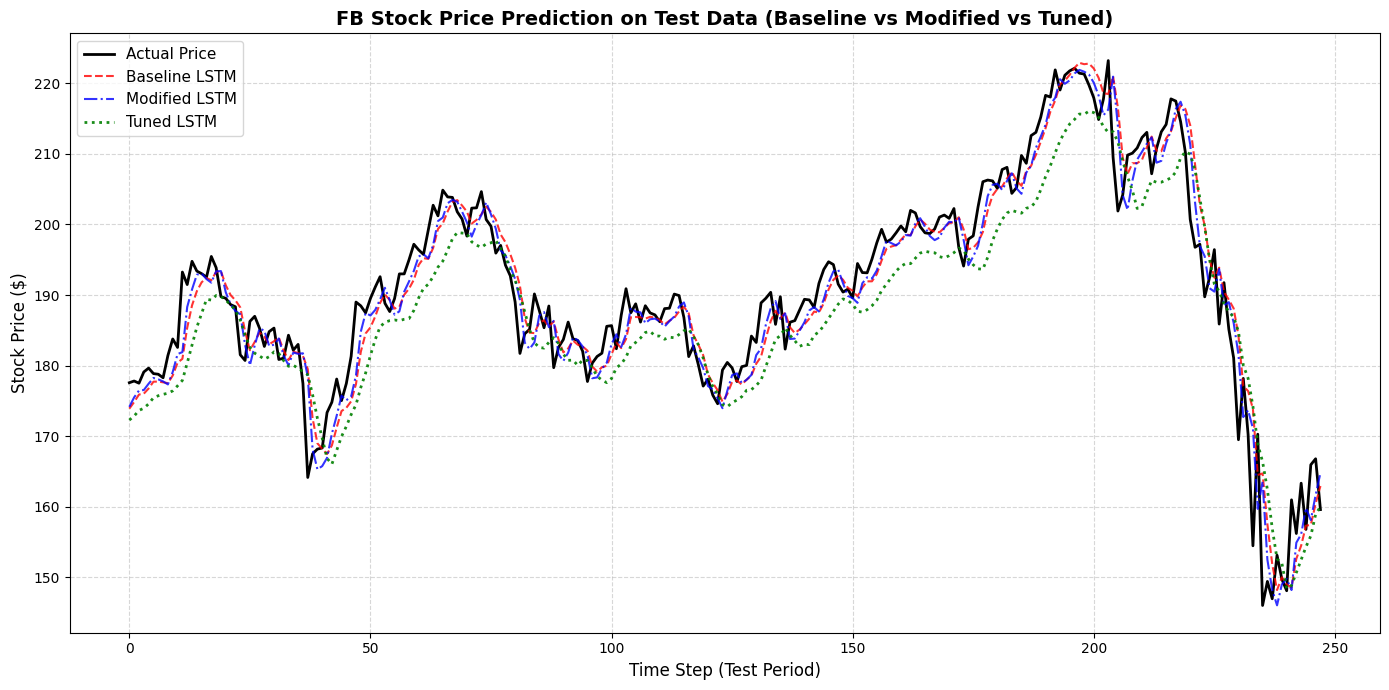

In [304]:
pred_fb = fb_scaler.inverse_transform(baseline_fb.predict(x_fb_test, verbose=0).reshape(-1, 1)).flatten()
pred_modified_fb = fb_scaler.inverse_transform(fb_modified.predict(x_fb_test, verbose=0).reshape(-1, 1)).flatten()
tuned_pred_fb = fb_scaler.inverse_transform(tuned_fb.predict(x_fb_test, verbose=0).reshape(-1, 1)).flatten()
actual_fb = fb_scaler.inverse_transform(np.asarray(y_fb_test).reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 7))
plt.plot(actual_fb, label='Actual Price', color='black', linewidth=2)
plt.plot(pred_fb, label='Baseline LSTM', color='red', linestyle='--', alpha=0.8)
plt.plot(pred_modified_fb, label='Modified LSTM', color='blue', linestyle='-.', alpha=0.8)
plt.plot(tuned_pred_fb, label='Tuned LSTM', color='green', linestyle=':', linewidth=2, alpha=0.9)
plt.title('FB Stock Price Prediction on Test Data (Baseline vs Modified vs Tuned)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (Test Period)', fontsize=12)
plt.ylabel('Stock Price ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pada grafik prediksi harga saham FB, **Modified Model** menunjukkan kemampuan mengikuti pergerakan harga aktual yang paling baik dibandingkan model lainnya. Kurva prediksi model ini cenderung lebih dekat dengan data aktual, baik pada saat tren naik maupun turun, sehingga menghasilkan nilai RMSE, MAE, dan MAPE terendah. **Baseline Model** juga mampu menangkap pola pergerakan harga secara umum, tetapi masih terlihat sedikit tertinggal ketika terjadi perubahan harga yang lebih cepat. Sementara itu, **Tuned Model** menghasilkan prediksi yang lebih halus dan cenderung menyimpang dari harga aktual, terutama pada periode dengan fluktuasi yang lebih besar. Secara keseluruhan, grafik ini menunjukkan bahwa penambahan kapasitas LSTM dan dense layer pada Modified Model berhasil meningkatkan kemampuan model dalam mempelajari pola temporal dan hubungan nonlinier pada data FB, sehingga prediksi yang dihasilkan lebih akurat dibandingkan Baseline maupun Tuned Model.


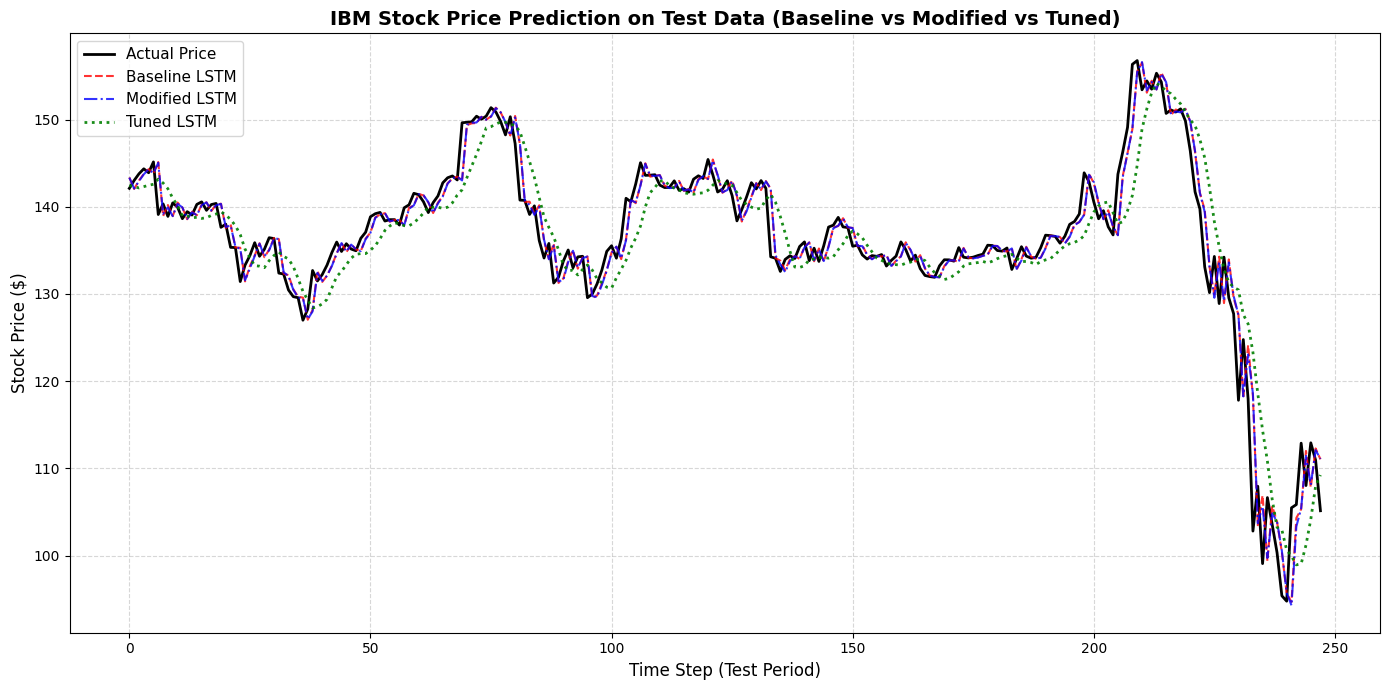

In [305]:
pred_ibm = ibm_scaler.inverse_transform(baseline_ibm.predict(x_ibm_test, verbose=0).reshape(-1, 1)).flatten()
pred_modified_ibm = ibm_scaler.inverse_transform(ibm_modified.predict(x_ibm_test, verbose=0).reshape(-1, 1)).flatten()
tuned_pred_ibm = ibm_scaler.inverse_transform(tuned_ibm.predict(x_ibm_test, verbose=0).reshape(-1, 1)).flatten()
actual_ibm = ibm_scaler.inverse_transform(np.asarray(y_ibm_test).reshape(-1, 1)).flatten()

plt.figure(figsize=(14, 7))
plt.plot(actual_ibm, label='Actual Price', color='black', linewidth=2)
plt.plot(pred_ibm, label='Baseline LSTM', color='red', linestyle='--', alpha=0.8)
plt.plot(pred_modified_ibm, label='Modified LSTM', color='blue', linestyle='-.', alpha=0.8)
plt.plot(tuned_pred_ibm, label='Tuned LSTM', color='green', linestyle=':', linewidth=2, alpha=0.9)
plt.title('IBM Stock Price Prediction on Test Data (Baseline vs Modified vs Tuned)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (Test Period)', fontsize=12)
plt.ylabel('Stock Price ($)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Pada grafik prediksi harga saham IBM, ketiga model menghasilkan kurva yang sangat berdekatan dan hampir menempel pada harga aktual sepanjang periode pengujian. Hal ini menunjukkan bahwa seluruh model telah mampu menangkap pola pergerakan harga dengan baik, sejalan dengan tingkat kesalahan yang secara umum sudah rendah. Perbedaan visual antara Baseline Model dan Modified Model hampir tidak terlihat karena keduanya sama-sama mampu mengikuti tren data secara akurat. Namun, jika dilihat dari hasil evaluasi, Modified Model tetap menunjukkan performa terbaik dibandingkan model lainnya, meskipun peningkatannya relatif kecil. Sementara itu, Tuned Model cenderung menghasilkan prediksi yang lebih halus namun sedikit tertinggal saat terjadi perubahan harga yang lebih cepat, sehingga kurang responsif terhadap fluktuasi. Secara keseluruhan, karakteristik data IBM yang relatif stabil membuat Baseline Model sudah cukup kuat, tetapi modifikasi yang dilakukan tetap memberikan peningkatan konsistensi akurasi, sehingga Modified Model dapat dianggap sebagai model terbaik untuk dataset ini.
